# 城市形态-能源交互多尺度数据处理框架

## 1. 项目结构设计



In [1]:
# urban_energy_analysis/
# ├── data/
# │   ├── raw/
# │   ├── processed/
# │   └── interim/
# ├── src/
# │   ├── data_processing/
# │   │   ├── morphology.py
# │   │   ├── energy.py
# │   │   └── integration.py
# │   ├── models/
# │   └── visualization/
# ├── notebooks/
# └── requirements.txt



## 2. 数据预处理核心代码

### 城市形态数据处理



In [5]:
# import geopandas as gpd
# import numpy as np
# import pandas as pd
# from shapely.geometry import box

# class MorphologyProcessor:
#     def __init__(self, data_path):
#         self.data_path = data_path
    
#     def process_building_footprints(self, shapefile_path):
#         """处理武汉建筑足迹数据"""
#         # 读取建筑数据
#         gdf = gpd.read_file(shapefile_path)
        
#         # 基础形态指标计算
#         gdf['building_area'] = gdf.geometry.area  # 建筑面积
#         gdf['building_perimeter'] = gdf.geometry.length  # 建筑周长
#         gdf['building_density'] = gdf.geometry.area / gdf.geometry.envelope.area  # 建筑密度
        
#         # 计算建筑形状指数
#         gdf['shape_index'] = gdf['building_perimeter'] / (4 * np.sqrt(gdf['building_area']))
        
#         # 计算高度相关指标
#         if 'height' in gdf.columns:
#             gdf['height_ratio'] = gdf['height'] / gdf['building_area']
#             gdf['volume'] = gdf['building_area'] * gdf['height']
        
#         return gdf

#     def _calculate_far(self, gdf):
#         """计算容积率"""
#         if 'height' in gdf.columns:
#             total_floor_area = np.sum(gdf['building_area'] * (gdf['height'] / 3))  # 假设每层高3米
#             total_area = gdf.total_bounds[2] * gdf.total_bounds[3]
#             return total_floor_area / total_area
#         return None

#     def _calculate_coverage(self, gdf):
#         """计算建筑覆盖率"""
#         total_building_area = gdf.geometry.area.sum()
#         total_area = (gdf.total_bounds[2] - gdf.total_bounds[0]) * (gdf.total_bounds[3] - gdf.total_bounds[1])
#         return total_building_area / total_area

#     def calculate_block_metrics(self, gdf, block_size=500):
#         """计算街区尺度的形态指标"""
#         # 创建网格
#         bounds = gdf.total_bounds
#         x_min, y_min, x_max, y_max = bounds
        
#         blocks = []
#         for x in np.arange(x_min, x_max, block_size):
#             for y in np.arange(y_min, y_max, block_size):
#                 block = box(x, y, x + block_size, y + block_size)
#                 blocks.append(block)
        
#         blocks_gdf = gpd.GeoDataFrame(geometry=blocks)
        
#         # 空间连接并计算指标
#         joined = gpd.sjoin(gdf, blocks_gdf, how='right', predicate='intersects')
#         block_metrics = joined.groupby(level=0).agg({
#             'building_area': 'sum',
#             'height': 'mean',
#             'building_density': 'mean'
#         }).reset_index()
        
#         return block_metrics

# # 使用示例
# if __name__ == "__main__":
#     filepath = r"F:\ScientificDatabase\paper03\wuhan_district\Wuhan_Buildings_Fine-Grained_Semantically_Enriched_Data_0228.shp"
#     processor = MorphologyProcessor("data/raw/")
    
#     # 处理建筑数据
#     buildings_gdf = processor.process_building_footprints(filepath)
    
#     # 计算街区尺度指标
#     block_metrics = processor.calculate_block_metrics(buildings_gdf)
    
#     # 保存处理后的数据
#     buildings_gdf.to_file("processed_buildings.gpkg", driver="GPKG")
#     block_metrics.to_file("block_metrics.gpkg", driver="GPKG")

In [6]:
import geopandas as gpd
import pandas as pd

# 读取建筑数据
filepath = r"F:\ScientificDatabase\paper03\wuhan_district\Wuhan_Buildings_Fine-Grained_Semantically_Enriched_Data_0228.shp"
gdf = gpd.read_file(filepath)

# 基本信息查看
print("数据基本信息：")
print("-" * 50)
print(f"数据条数: {len(gdf)}")
print(f"数据列名: {gdf.columns.tolist()}")
print("\n数据类型信息：")
print("-" * 50)
print(gdf.dtypes)

# 数据统计描述
print("\n数据统计描述：")
print("-" * 50)
print(gdf.describe())

# 查看前几行数据
print("\n数据预览：")
print("-" * 50)
print(gdf.head())

# 检查空值情况
print("\n空值统计：")
print("-" * 50)
print(gdf.isnull().sum())

# 空间范围信息
print("\n空间范围：")
print("-" * 50)
print(f"总边界框: {gdf.total_bounds}")
print(f"坐标系统: {gdf.crs}")

数据基本信息：
--------------------------------------------------
数据条数: 982576
数据列名: ['fid', 'Height', 'area', 'area_m2', 'area_class', 'index_righ', 'Lon', 'Lat', 'F_AREA', 'City_CODE', 'UUID', 'Level1', 'Level2', 'Level1_cn', 'Level2_cn', 'geometry']

数据类型信息：
--------------------------------------------------
fid            float64
Height         float64
area           float64
area_m2        float64
area_class      object
index_righ     float64
Lon            float64
Lat            float64
F_AREA         float64
City_CODE      float64
UUID           float64
Level1         float64
Level2         float64
Level1_cn       object
Level2_cn       object
geometry      geometry
dtype: object

数据统计描述：
--------------------------------------------------
                fid         Height      area        area_m2     index_righ  \
count  9.825760e+05  982576.000000  982576.0  982576.000000  450149.000000   
mean   6.355772e+05       9.555733       0.0     291.822370    2504.078578   
std    3.414271e+0


建筑高度分析
--------------------------------------------------
高度统计信息：
count    982576.000000
mean          9.555733
std           7.305912
min          -1.429694
25%           5.886958
50%           7.445006
75%          10.568981
max         188.094740
Name: Height, dtype: float64

各高度类别建筑数量：
height_category
0-10m      710593
10-20m     212010
20-30m      41369
30-50m      13707
50-100m      4201
>100m         457
Name: count, dtype: int64


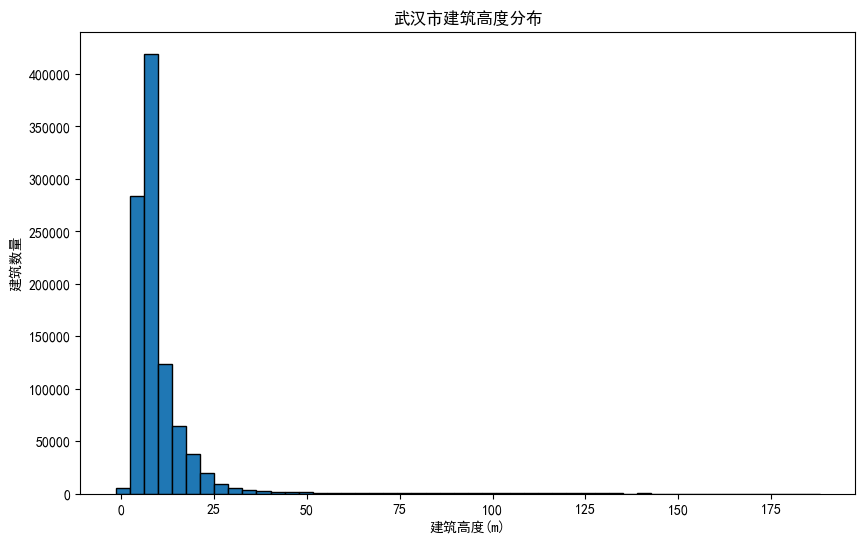


建筑面积分析
--------------------------------------------------
面积统计信息：
count    982576.000000
mean        291.822370
std        1373.138907
min          20.000000
25%          59.190000
50%         107.990000
75%         235.760000
max      345123.090000
Name: area_m2, dtype: float64

各面积类别建筑数量：
area_category
<100㎡          444044
100-500㎡       430266
500-1000㎡       69487
1000-5000㎡      33930
5000-10000㎡      2988
>10000㎡          1861
Name: count, dtype: int64

建筑类型分析
--------------------------------------------------
一级分类统计：
Level1
1.0    194933
3.0    119679
5.0     84263
2.0     33787
4.0     17487
Name: count, dtype: int64

二级分类统计：
前10个二级分类：
Level2
101.0    194933
301.0    119679
202.0     28025
502.0     26023
501.0     20665
505.0     18788
403.0     16200
504.0     11191
503.0      7596
201.0      5762
Name: count, dtype: int64


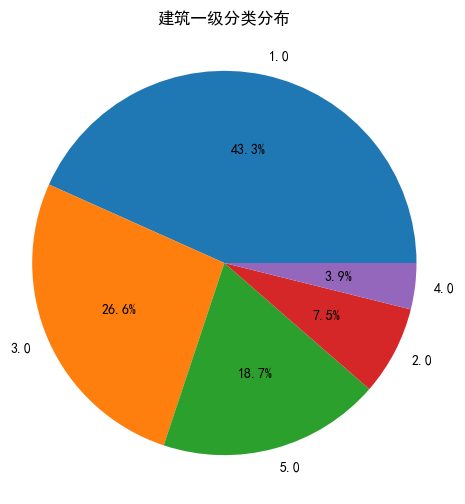


建筑形态指标分析
--------------------------------------------------
形态指标统计：
       floor_area_ratio  building_coverage_ratio
count     982576.000000            982576.000000
mean           3.185244                 0.632415
std            2.435304                 0.182832
min           -0.476565                 0.034396
25%            1.962319                 0.498248
50%            2.481669                 0.590910
75%            3.522994                 0.789036
max           62.698247                 0.999496


In [7]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False

# 1. 建筑高度分析
def analyze_building_height(gdf):
    print("\n建筑高度分析")
    print("-" * 50)
    height_stats = gdf['Height'].describe()
    print("高度统计信息：")
    print(height_stats)
    
    # 创建高度分类
    height_bins = [0, 10, 20, 30, 50, 100, np.inf]
    height_labels = ['0-10m', '10-20m', '20-30m', '30-50m', '50-100m', '>100m']
    gdf['height_category'] = pd.cut(gdf['Height'], bins=height_bins, labels=height_labels)
    
    # 统计各高度类别的建筑数量
    height_dist = gdf['height_category'].value_counts().sort_index()
    print("\n各高度类别建筑数量：")
    print(height_dist)
    
    # 绘制高度分布直方图
    plt.figure(figsize=(10, 6))
    plt.hist(gdf['Height'], bins=50, edgecolor='black')
    plt.title('武汉市建筑高度分布')
    plt.xlabel('建筑高度(m)')
    plt.ylabel('建筑数量')
    plt.show()

# 2. 建筑面积分析
def analyze_building_area(gdf):
    print("\n建筑面积分析")
    print("-" * 50)
    area_stats = gdf['area_m2'].describe()
    print("面积统计信息：")
    print(area_stats)
    
    # 创建面积分类
    area_bins = [0, 100, 500, 1000, 5000, 10000, np.inf]
    area_labels = ['<100㎡', '100-500㎡', '500-1000㎡', '1000-5000㎡', '5000-10000㎡', '>10000㎡']
    gdf['area_category'] = pd.cut(gdf['area_m2'], bins=area_bins, labels=area_labels)
    
    # 统计各面积类别的建筑数量
    area_dist = gdf['area_category'].value_counts().sort_index()
    print("\n各面积类别建筑数量：")
    print(area_dist)

# 3. 建筑类型分析
def analyze_building_types(gdf):
    print("\n建筑类型分析")
    print("-" * 50)
    # Level1分类统计
    print("一级分类统计：")
    level1_counts = gdf['Level1'].value_counts()
    print(level1_counts)
    
    # Level2分类统计
    print("\n二级分类统计：")
    level2_counts = gdf['Level2'].value_counts().head(10)
    print("前10个二级分类：")
    print(level2_counts)
    
    # 绘制分类饼图
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.pie(level1_counts, labels=level1_counts.index, autopct='%1.1f%%')
    plt.title('建筑一级分类分布')
    plt.axis('equal')
    plt.show()

# 4. 形态指标计算
def calculate_morphology_metrics(gdf):
    print("\n建筑形态指标分析")
    print("-" * 50)
    
    # 计算建筑密度指标
    gdf['floor_area_ratio'] = gdf['Height'] * gdf['area_m2'] / (gdf['area_m2'] * 3)  # 假设每层3米
    gdf['building_coverage_ratio'] = gdf['area_m2'] / gdf.geometry.envelope.area
    
    print("形态指标统计：")
    metrics_stats = gdf[['floor_area_ratio', 'building_coverage_ratio']].describe()
    print(metrics_stats)

# 执行分析
analyze_building_height(gdf)
analyze_building_area(gdf)
analyze_building_types(gdf)
calculate_morphology_metrics(gdf)

# 保存分析结果
output_path = "wuhan_building_analysis_results.csv"
gdf.to_csv(output_path, encoding='utf-8')

## SVF sky view factor 计算
sky view factor	天空视角系数的定义是，从二维表述中看到的某一观测点上方的可见天空部分。它已被广泛用作城市冠层参数之一。


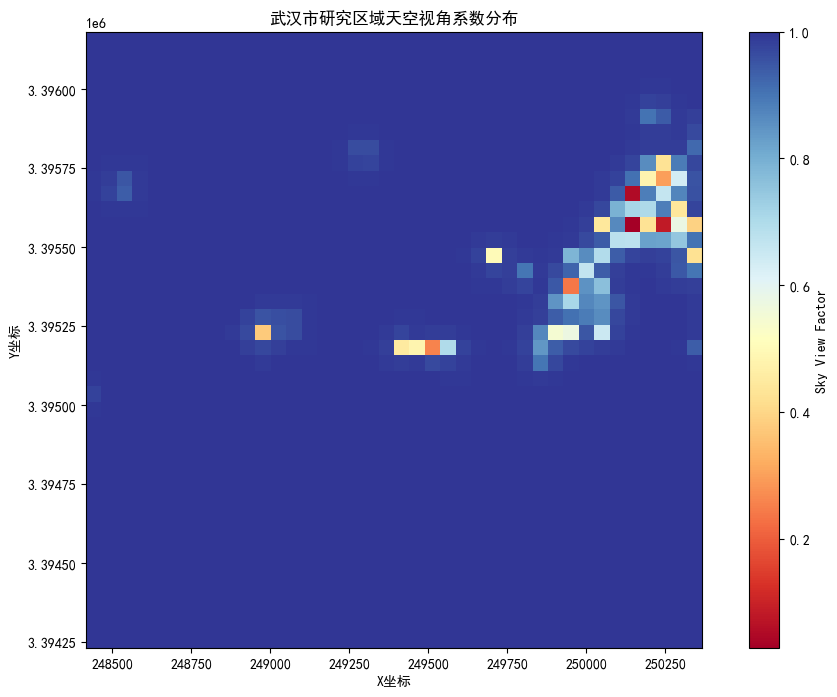


天空视角系数统计：
--------------------------------------------------
平均SVF: 0.985
最小SVF: 0.028
最大SVF: 1.000
标准差: 0.078


In [14]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import math

def calculate_svf(gdf, sample_point, radius=100):
    """
    计算指定点的天空视角系数
    
    参数:
    gdf: GeoDataFrame，包含建筑物数据
    sample_point: Point，观测点
    radius: float，考虑范围的半径（米）
    """
    # 创建缓冲区
    buffer_circle = sample_point.buffer(radius)
    
    # 筛选缓冲区内的建筑
    mask = gdf.geometry.intersects(buffer_circle)
    buildings_in_range = gdf[mask]
    
    if len(buildings_in_range) == 0:
        return 1.0  # 如果范围内没有建筑，返回1
    
    # 计算SVF
    angles = 360  # 方位角数量
    svf_values = []
    
    for angle in range(angles):
        theta = math.radians(angle)
        max_beta = 0
        
        for _, building in buildings_in_range.iterrows():
            # 计算建筑到观测点的距离和方位角
            dx = building.geometry.centroid.x - sample_point.x
            dy = building.geometry.centroid.y - sample_point.y
            distance = math.sqrt(dx**2 + dy**2)
            
            if distance > 0:  # 避免除以零
                # 计算建筑物的仰角
                beta = math.atan2(building['Height'], distance)
                max_beta = max(max_beta, beta)
        
        svf_values.append(math.cos(max_beta)**2)
    
    # 计算平均SVF
    return sum(svf_values) / len(svf_values)

def analyze_area_svf(gdf, area_bounds, grid_size=50):
    """
    分析特定区域的SVF分布
    
    参数:
    gdf: GeoDataFrame，建筑数据
    area_bounds: tuple，区域边界 (minx, miny, maxx, maxy)
    grid_size: float，网格大小（米）
    """
    minx, miny, maxx, maxy = area_bounds
    
    # 创建采样网格
    x_coords = np.arange(minx, maxx, grid_size)
    y_coords = np.arange(miny, maxy, grid_size)
    
    svf_matrix = np.zeros((len(y_coords), len(x_coords)))
    
    # 计算每个网格点的SVF
    for i, y in enumerate(y_coords):
        for j, x in enumerate(x_coords):
            point = Point(x, y)
            svf = calculate_svf(gdf, point)
            svf_matrix[i, j] = svf
    
    return svf_matrix, x_coords, y_coords

# 选择研究区域（以武汉某个片区为例）
# 这里以总边界的一小部分为例
bounds = gdf.total_bounds
center_x = (bounds[0] + bounds[2]) / 2
center_y = (bounds[1] + bounds[3]) / 2
study_area_size = 2000  # 研究区域大小（米）

study_area_bounds = (
    center_x - study_area_size/2,
    center_y - study_area_size/2,
    center_x + study_area_size/2,
    center_y + study_area_size/2
)

# 计算SVF
svf_matrix, x_coords, y_coords = analyze_area_svf(gdf, study_area_bounds)

# 可视化结果
plt.figure(figsize=(12, 8))
plt.imshow(svf_matrix, extent=[x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]], 
           cmap='RdYlBu', origin='lower')
plt.colorbar(label='Sky View Factor')
plt.title('武汉市研究区域天空视角系数分布')
plt.xlabel('X坐标')
plt.ylabel('Y坐标')
plt.show()

# 输出统计信息
print("\n天空视角系数统计：")
print("-" * 50)
print(f"平均SVF: {np.mean(svf_matrix):.3f}")
print(f"最小SVF: {np.min(svf_matrix):.3f}")
print(f"最大SVF: {np.max(svf_matrix):.3f}")
print(f"标准差: {np.std(svf_matrix):.3f}")

In [17]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import folium
from branca.colormap import LinearColormap
import pandas as pd

def plot_svf_with_folium(svf_matrix, x_coords, y_coords, gdf, study_area_bounds):
    """使用folium创建交互式地图可视化SVF分布"""
    # 计算研究区域中心点
    center_lat = (study_area_bounds[1] + study_area_bounds[3]) / 2
    center_lon = (study_area_bounds[0] + study_area_bounds[2]) / 2
    
    # 创建基础地图
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=15,
        tiles='cartodbpositron'
    )
    
    # 创建网格点数据
    grid_data = []
    for i, y in enumerate(y_coords):
        for j, x in enumerate(x_coords):
            grid_data.append({
                'lat': y,
                'lon': x,
                'svf': svf_matrix[i, j]
            })
    
    df = pd.DataFrame(grid_data)
    
    # 创建颜色映射
    colormap = LinearColormap(
        colors=['red', 'yellow', 'blue'],
        vmin=df['svf'].min(),
        vmax=df['svf'].max()
    )
    
    # 添加SVF点
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            color=None,
            fill=True,
            fillColor=colormap(row['svf']),
            fillOpacity=0.7,
            popup=f"SVF: {row['svf']:.3f}"
        ).add_to(m)
    
    # 添加颜色图例
    colormap.add_to(m)
    colormap.caption = 'Sky View Factor'
    
    # 添加研究区域边界
    bounds = [
        [study_area_bounds[1], study_area_bounds[0]],
        [study_area_bounds[1], study_area_bounds[2]],
        [study_area_bounds[3], study_area_bounds[2]],
        [study_area_bounds[3], study_area_bounds[0]]
    ]
    folium.Polygon(
        locations=bounds,
        color='red',
        fill=False,
        weight=2
    ).add_to(m)
    
    # 保存地图
    m.save('wuhan_svf_interactive.html')
    
    return m

# 安装所需包
# !pip install folium branca

# 首先，确保数据是在正确的坐标系统中
print("检查坐标系统：")
print(gdf.crs)

# 如果需要，转换到WGS84
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

# 创建交互式地图
m = plot_svf_with_folium(svf_matrix, x_coords, y_coords, gdf, study_area_bounds)

print("\n已生成交互式地图：wuhan_svf_interactive.html")
print("请在浏览器中打开查看完整的交互式地图")

# 输出统计信息
print("\n天空视角系数统计：")
print("-" * 50)
print(f"平均SVF: {np.mean(svf_matrix):.3f}")
print(f"最小SVF: {np.min(svf_matrix):.3f}")
print(f"最大SVF: {np.max(svf_matrix):.3f}")
print(f"标准差: {np.std(svf_matrix):.3f}")

检查坐标系统：
EPSG:32650

已生成交互式地图：wuhan_svf_interactive.html
请在浏览器中打开查看完整的交互式地图

天空视角系数统计：
--------------------------------------------------
平均SVF: 0.985
最小SVF: 0.028
最大SVF: 1.000
标准差: 0.078




### 能源数据清洗



In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

class EnergyDataCleaner:
    def __init__(self):
        self.scaler = StandardScaler()
    
    def clean_energy_data(self, energy_df):
        """清洗能源消耗数据"""
        # 处理缺失值
        energy_df.fillna(energy_df.mean(), inplace=True)
        
        # 异常值检测与处理
        z_scores = abs(self.scaler.fit_transform(energy_df))
        energy_df[z_scores > 3] = energy_df.mean()
        
        # 时间序列规范化
        energy_df.index = pd.to_datetime(energy_df.index)
        return energy_df

    def aggregate_energy_consumption(self, energy_df, scale='building'):
        """多尺度能源消耗聚合"""
        if scale == 'building':
            return energy_df.groupby('building_id').sum()
        elif scale == 'block':
            return energy_df.groupby('block_id').sum()
        elif scale == 'district':
            return energy_df.groupby('district_id').sum()



### 多尺度数据整合



In [ ]:
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler

class DataIntegrator:
    def __init__(self):
        self.scaler = MinMaxScaler()
    
    def integrate_datasets(self, morphology_gdf, energy_df):
        """整合形态和能源数据"""
        # 空间连接
        merged_data = gpd.sjoin(morphology_gdf, energy_df, how='left', op='contains')
        
        # 特征标准化
        numeric_columns = merged_data.select_dtypes(include=[np.number]).columns
        merged_data[numeric_columns] = self.scaler.fit_transform(merged_data[numeric_columns])
        
        return merged_data

    def create_multi_scale_index(self, integrated_data):
        """创建多尺度索引"""
        return pd.MultiIndex.from_arrays([
            integrated_data['district_id'],
            integrated_data['block_id'],
            integrated_data['building_id']
        ], names=['district', 'block', 'building'])



## 3. 使用示例



In [ ]:
# 示例使用代码
from src.data_processing.morphology import MorphologyProcessor
from src.data_processing.energy import EnergyDataCleaner
from src.data_processing.integration import DataIntegrator

# 初始化处理器
morphology_processor = MorphologyProcessor("data/raw/")
energy_cleaner = EnergyDataCleaner()
data_integrator = DataIntegrator()

# 处理形态数据
building_data = morphology_processor.process_building_footprints("buildings.shp")
urban_metrics = morphology_processor.calculate_urban_metrics(building_data)

# 清洗能源数据
energy_data = pd.read_csv("energy_consumption.csv")
clean_energy = energy_cleaner.clean_energy_data(energy_data)

# 整合数据
integrated_data = data_integrator.integrate_datasets(building_data, clean_energy)